# **Purpose**

Evaluates the **WordNet co-hyponym** (Track A, similarity-based) distractor
predictions produced by the matching generation notebook, using the
**identical metric suite** as the Track B (T5-base/BART-base/Flan-T5-base)
evaluation notebooks: BLEU, ROUGE-1/2/L, METEOR, GPT-2 perplexity,
Distinct-1/2, and distractor-vs-answer semantic similarity.

There's no model to load here — this notebook just reads
`wordnet_baseline_predictions.json` (written by the generation notebook) and scores it.

**If you're running this in a separate Kaggle session from the generation
notebook:** `/kaggle/working` is per-session, so this notebook won't see that
notebook's output automatically. Either run both notebooks in the same
session, or add the generation notebook's output as an **Input** to this one
(Add Input → Your Work → Notebook Output Files) — the cell below searches
both locations automatically.

## **Install dependencies**

In [1]:
!pip install -qU \
 evaluate \
 rouge_score \
 sacrebleu \
 nltk \
 sentence-transformers \
 matplotlib \
 torch \
 torchvision \
 torchaudio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.8/739.8 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42

## **Load the API Keys and Tokens**

In [2]:
from kaggle_secrets import UserSecretsClient
import os

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")   # must match the exact secret name you set in Kaggle Secrets

os.environ["HF_TOKEN"] = hf_token

In [3]:
import os
os.environ["NLTK_ALLOW_PROXIED_URLOPEN"] = "1"   # Kaggle's network proxy blocks NLTK's default fetch otherwise

import nltk

NLTK_DATA_DIR = "/kaggle/working/nltk_data"
os.makedirs(NLTK_DATA_DIR, exist_ok=True)
if NLTK_DATA_DIR not in nltk.data.path:
    nltk.data.path.insert(0, NLTK_DATA_DIR)

def ensure_nltk_resource(resource_path, download_name, max_attempts=3):
    for attempt in range(1, max_attempts + 1):
        try:
            nltk.data.find(resource_path)
            return True
        except LookupError:
            pass
        try:
            # force=True: re-download/re-extract even if NLTK thinks it's
            # already satisfied — this is what clears a stale/corrupt cache.
            nltk.download(download_name, download_dir=NLTK_DATA_DIR, quiet=True, force=True)
        except Exception as e:
            print(f"[{download_name}] download attempt {attempt} raised: {e}")
    try:
        nltk.data.find(resource_path)
        return True
    except LookupError:
        return False

RESOURCES = [('corpora/wordnet', 'wordnet'), ('corpora/omw-1.4', 'omw-1.4')]

missing = []
for resource_path, download_name in RESOURCES:
    ok = ensure_nltk_resource(resource_path, download_name)
    print(f"{download_name}: {'OK' if ok else 'STILL MISSING'}")
    if not ok:
        missing.append(download_name)

if missing:
    print(f"\nWARNING: could not obtain {missing} after retries. "
          f"Check that Internet is ON in Kaggle's Settings panel, then re-run this cell.")
else:
    print("\nAll required NLTK resources are available.")

wordnet: STILL MISSING
omw-1.4: STILL MISSING



## **Imports**

In [4]:
import json
import glob
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from sentence_transformers import SentenceTransformer, util as st_util
import evaluate

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cpu


## **Config**

In [5]:
METHOD_NAME = "wordnet_baseline"
PREDICTIONS_FILENAME = "wordnet_baseline_predictions.json"   # written by the matching generation notebook
OUTPUT_JSON = "/kaggle/working/eval_results_wordnet_baseline.json"

## **Load predictions produced by the generation notebook**

Searches this notebook's own `/kaggle/working` first (same-session run),
then falls back to anything found under `/kaggle/input/` (in case the
generation notebook's output was attached as an Input dataset instead).

In [6]:
candidate_paths = [f"/kaggle/working/{PREDICTIONS_FILENAME}"] + sorted(
    glob.glob(f"/kaggle/input/**/{PREDICTIONS_FILENAME}", recursive=True)
)

PREDICTIONS_JSON = next((p for p in candidate_paths if os.path.exists(p)), None)

if PREDICTIONS_JSON is None:
    raise FileNotFoundError(
        f"Could not find {PREDICTIONS_FILENAME}.\n"
        f"This file is written by the matching generation notebook. Either:\n"
        f"  1) Run the generation notebook in THIS SAME Kaggle session before this cell, or\n"
        f"  2) Add the generation notebook's output as an Input to this notebook "
        f"(Add Input > Your Work > Notebook Output Files), then re-run this cell.\n"
        f"Searched: {candidate_paths}"
    )

print(f"Using predictions file: {PREDICTIONS_JSON}")

with open(PREDICTIONS_JSON) as f:
    data = json.load(f)

predictions = data["predictions"]
references = data["references"]
correct_answers = data["correct_answers"]

print(f"Loaded {len(predictions)} predictions from {PREDICTIONS_JSON}")
print(f"Method metadata: test_size={data.get('test_size')}, seed={data.get('seed')}")

Using predictions file: /kaggle/input/notebooks/gauravdey777/36-generate-wordnet-baseline-race-distractor/wordnet_baseline_predictions.json
Loaded 1500 predictions from /kaggle/input/notebooks/gauravdey777/36-generate-wordnet-baseline-race-distractor/wordnet_baseline_predictions.json
Method metadata: test_size=1500, seed=42


## **Reference-based metrics: BLEU, ROUGE-1/2/L, METEOR**

In [7]:
bleu = evaluate.load("sacrebleu")
rouge = evaluate.load("rouge")
meteor = evaluate.load("meteor")

# BLEU/ROUGE/METEOR need non-empty hypotheses; substitute a placeholder for
# any item where the baseline found no candidate at all so metrics don't error.
safe_predictions = [p if p.strip() else "[no candidate found]" for p in predictions]

bleu_score = bleu.compute(
    predictions=safe_predictions, references=[[r] for r in references]
)["score"]

rouge_scores = rouge.compute(predictions=safe_predictions, references=references)

meteor_score = meteor.compute(predictions=safe_predictions, references=references)["meteor"]

print(f"BLEU:    {bleu_score:.4f}")
print(f"ROUGE-1: {rouge_scores['rouge1']:.4f}")
print(f"ROUGE-2: {rouge_scores['rouge2']:.4f}")
print(f"ROUGE-L: {rouge_scores['rougeL']:.4f}")
print(f"METEOR:  {meteor_score:.4f}")

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


BLEU:    3.8461
ROUGE-1: 0.1488
ROUGE-2: 0.0401
ROUGE-L: 0.1423
METEOR:  0.1347


## **Diversity metrics: Distinct-1 / Distinct-2**

Corpus-level, reference-free — flags a baseline that keeps returning the same
handful of generic candidates regardless of question.

In [8]:
def distinct_n(preds, n):
    all_ngrams = []
    for pred in preds:
        tokens = pred.split()
        ngrams = list(zip(*[tokens[i:] for i in range(n)]))
        all_ngrams.extend(ngrams)
    if not all_ngrams:
        return 0.0
    return len(set(all_ngrams)) / len(all_ngrams)


distinct_1 = distinct_n(safe_predictions, 1)
distinct_2 = distinct_n(safe_predictions, 2)

print(f"Distinct-1: {distinct_1:.4f}")
print(f"Distinct-2: {distinct_2:.4f}")

Distinct-1: 0.2974
Distinct-2: 0.7201


## **Fluency metric: GPT-2 perplexity**

Reference-free — measures how natural the generated distractors read on
their own. Lexical-substitution baselines often score poorly here since
swapping one word can leave the surrounding phrase ungrammatical.

In [9]:
gpt2_tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
gpt2_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
gpt2_model.eval()

perplexities = []
with torch.no_grad():
    for text in safe_predictions:
        if not text.strip():
            continue
        encodings = gpt2_tokenizer(text, return_tensors="pt").to(device)
        input_ids = encodings["input_ids"]
        if input_ids.shape[1] < 2:
            continue  # too short to compute a meaningful loss
        outputs = gpt2_model(input_ids, labels=input_ids)
        perplexities.append(torch.exp(outputs.loss).item())

perplexity = float(np.mean(perplexities)) if perplexities else float("nan")
print(f"GPT-2 perplexity: {perplexity:.4f}")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


GPT-2 perplexity: 6650.2924


## **Semantic plausibility: distractor-vs-answer cosine similarity**

A good distractor should be *related* to the correct answer (high-ish
similarity) without being so close that it could also be considered correct.
Same metric and threshold as the Track B evaluation notebooks, so the
plausibility-validity trade-off is directly comparable across every method.

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Mean distractor-answer similarity: 0.5947
Std dev: 0.2882
% of distractors with similarity > 0.9 (risk of being a valid alternative answer): 9.7%


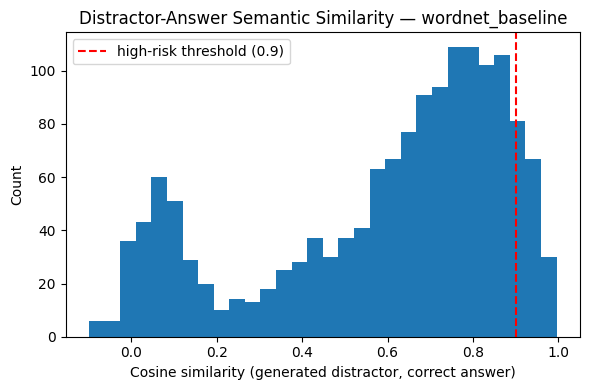

In [10]:
embedder = SentenceTransformer("all-MiniLM-L6-v2")

pred_emb = embedder.encode(safe_predictions, convert_to_tensor=True, show_progress_bar=True)
answer_emb = embedder.encode(correct_answers, convert_to_tensor=True, show_progress_bar=True)

similarities = st_util.cos_sim(pred_emb, answer_emb).diagonal().cpu().numpy()

mean_similarity = float(similarities.mean())
pct_high_risk = float((similarities > 0.9).mean() * 100)

print(f"Mean distractor-answer similarity: {mean_similarity:.4f}")
print(f"Std dev: {similarities.std():.4f}")
print(f"% of distractors with similarity > 0.9 (risk of being a valid alternative answer): "
      f"{pct_high_risk:.1f}%")

plt.figure(figsize=(6, 4))
plt.hist(similarities, bins=30)
plt.axvline(0.9, color="red", linestyle="--", label="high-risk threshold (0.9)")
plt.xlabel("Cosine similarity (generated distractor, correct answer)")
plt.ylabel("Count")
plt.title(f"Distractor-Answer Semantic Similarity — {METHOD_NAME}")
plt.legend()
plt.tight_layout()
plt.savefig(f"/kaggle/working/similarity_distribution_{METHOD_NAME}.png", dpi=150)
plt.show()

## **Assemble and save results**

In [11]:
results = {
    "method": METHOD_NAME,
    "test_size": data.get("test_size"),
    "seed": data.get("seed"),
    "bleu": bleu_score,
    "rouge1": rouge_scores["rouge1"],
    "rouge2": rouge_scores["rouge2"],
    "rougeL": rouge_scores["rougeL"],
    "meteor": meteor_score,
    "gpt2_perplexity": perplexity,
    "distinct_1": distinct_1,
    "distinct_2": distinct_2,
    "mean_answer_similarity": mean_similarity,
    "pct_high_risk_similarity": pct_high_risk,
}

print("=== Results ===")
for k, v in results.items():
    if isinstance(v, float):
        print(f"{k:20s}: {v:.4f}")
    else:
        print(f"{k:20s}: {v}")

with open(OUTPUT_JSON, "w") as f:
    json.dump(
        {
            "results": results,
            "sample_predictions": [
                {"correct_answer": a, "gold_distractor": r, "generated_distractor": p}
                for a, r, p in list(zip(correct_answers, references, predictions))[:10]
            ],
        },
        f,
        indent=2,
    )

print(f"\nSaved results + sample predictions to {OUTPUT_JSON}")

=== Results ===
method              : wordnet_baseline
test_size           : 1500
seed                : 42
bleu                : 3.8461
rouge1              : 0.1488
rouge2              : 0.0401
rougeL              : 0.1423
meteor              : 0.1347
gpt2_perplexity     : 6650.2924
distinct_1          : 0.2974
distinct_2          : 0.7201
mean_answer_similarity: 0.5947
pct_high_risk_similarity: 9.7333

Saved results + sample predictions to /kaggle/working/eval_results_wordnet_baseline.json


## **Inspect sample generations**

In [12]:
for a, r, p in list(zip(correct_answers, references, predictions))[:10]:
    print(f"Correct answer:       {a}")
    print(f"Gold distractor:      {r}")
    print(f"Generated distractor: {p if p else '(no candidate found)'}")
    print("-" * 80)

Correct answer:       Working or talking with students.
Gold distractor:      Having a basketball game.
Generated distractor: (no candidate found)
--------------------------------------------------------------------------------
Correct answer:       we must know who we are
Gold distractor:      we should know what we do
Generated distractor: we must know who we quarter section
--------------------------------------------------------------------------------
Correct answer:       the high quality education and research and the wide range of courses
Gold distractor:      the convenient traffic
Generated distractor: the high quality education and research and the wide range of coeducation
--------------------------------------------------------------------------------
Correct answer:       they watch TV late
Gold distractor:      they play the computer games late into the night
Generated distractor: they watch radio late
---------------------------------------------------------------------

## **Next steps**

- Collect `/kaggle/working/eval_results_wordnet_baseline.json` alongside the Track B `eval_results_*.json` files
  into one master comparison table — this baseline is the floor the
  fine-tuned models (Track B) and LLM-prompted methods (Track C) should beat.
- Compare `mean_answer_similarity` / `pct_high_risk_similarity` against
  Track B's numbers: WordNet co-hyponym typically sits at the opposite end of
  the plausibility-validity trade-off from a fine-tuned generative model.